<a href="https://colab.research.google.com/github/innsvi/python_for_ds_task/blob/main/HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Завантаження даних
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/data/yulu_rental.csv')

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [5]:
monthly_avg = df['count'].resample('M').mean()
monthly_avg.head()

/tmp/ipykernel_7383/3427924991.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['count'].resample('M').mean()


,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211


Text(0, 0.5, 'Середня кількість оренд')

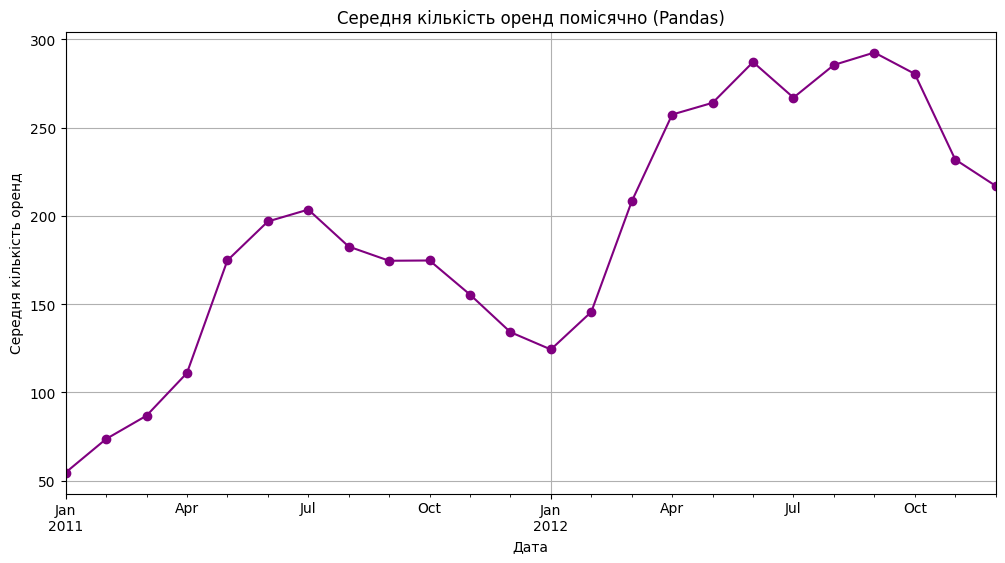

In [6]:
ax = monthly_avg.plot(
    figsize=(12, 6),
    marker='o',
    color='purple',
    title='Середня кількість оренд помісячно (Pandas)',
    grid=True
)

ax.set_xlabel('Дата')
ax.set_ylabel('Середня кількість оренд')

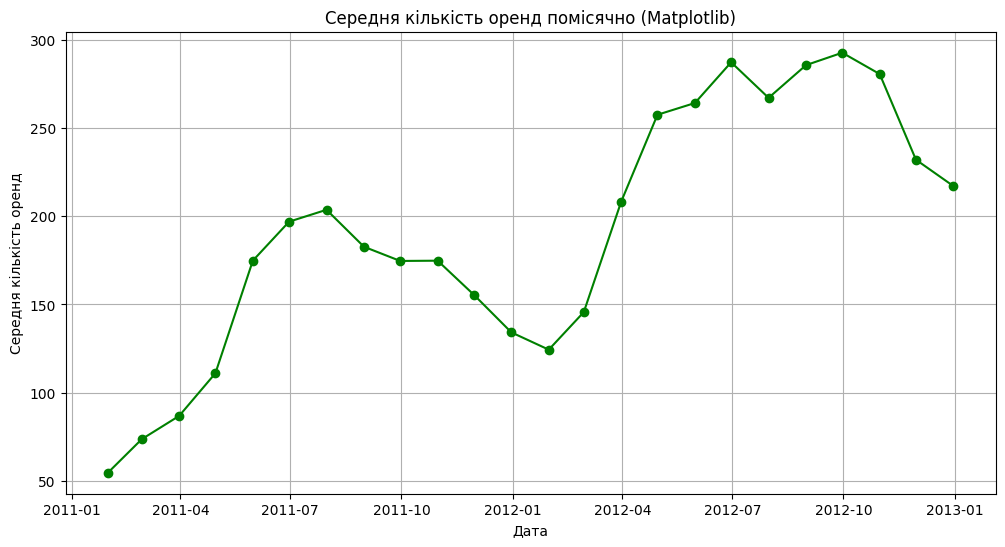

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='green')
plt.title('Середня кількість оренд помісячно (Matplotlib)')
plt.xlabel('Дата')
plt.ylabel('Середня кількість оренд')
plt.grid(True)
plt.show()

Обидва графіки показують однакову динаміку, оскільки побудовані на одних і тих самих даних, але відрізняються способом оформлення осі часу та базовим стилем. Графік через Pandas виглядає компактніше і будується простіше, а графік через Matplotlib дає більше контролю над налаштуваннями.

Особисто мені більше подобається варіант через Pandas, бо він швидший у побудові та виглядає більш читабельно для базового аналізу. Якщо ж потрібне тонке налаштування візуалізації, то зручніше використовувати Matplotlib.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [8]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

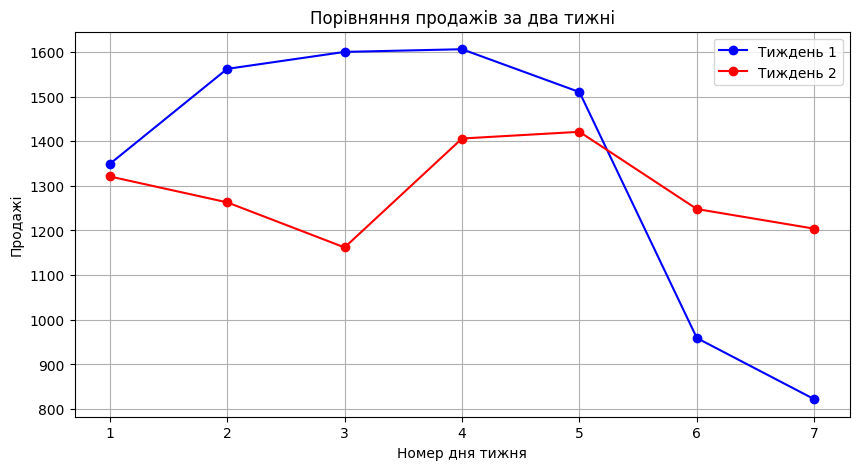

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(days, sales_week1, marker='o', color='blue', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', color='red', label='Тиждень 2')

plt.title('Порівняння продажів за два тижні')
plt.xlabel('Номер дня тижня')
plt.ylabel('Продажі')
plt.legend()
plt.grid(True)

plt.show()

**1. В який тиждень продажі були стабільніші**?
Судячи з графіка, у другий тиждень продажі були стабільніші, бо лінія змінюється більш плавно і без різких спадів. У першому тижні наприкінці видно сильне падіння продажів.

**2. Чи можна підкріпити висновок обчисленнями**?
Так, це можна перевірити за допомогою стандартного відхилення або розмаху значень (max - min). У стабільнішого тижня ці показники мають бути меншими, бо значення менше відхиляються від середнього.

In [10]:
print("Стандартне відхилення, тиждень 1:", np.std(sales_week1))
print("Стандартне відхилення, тиждень 2:", np.std(sales_week2))

print("Розмах, тиждень 1:", max(sales_week1) - min(sales_week1))
print("Розмах, тиждень 2:", max(sales_week2) - min(sales_week2))

Стандартне відхилення, тиждень 1: 299.99857142517004
Стандартне відхилення, тиждень 2: 90.9060964256355
Розмах, тиждень 1: 784
Розмах, тиждень 2: 259


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

/tmp/ipykernel_7383/598129725.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df['temp'].resample('M').mean()


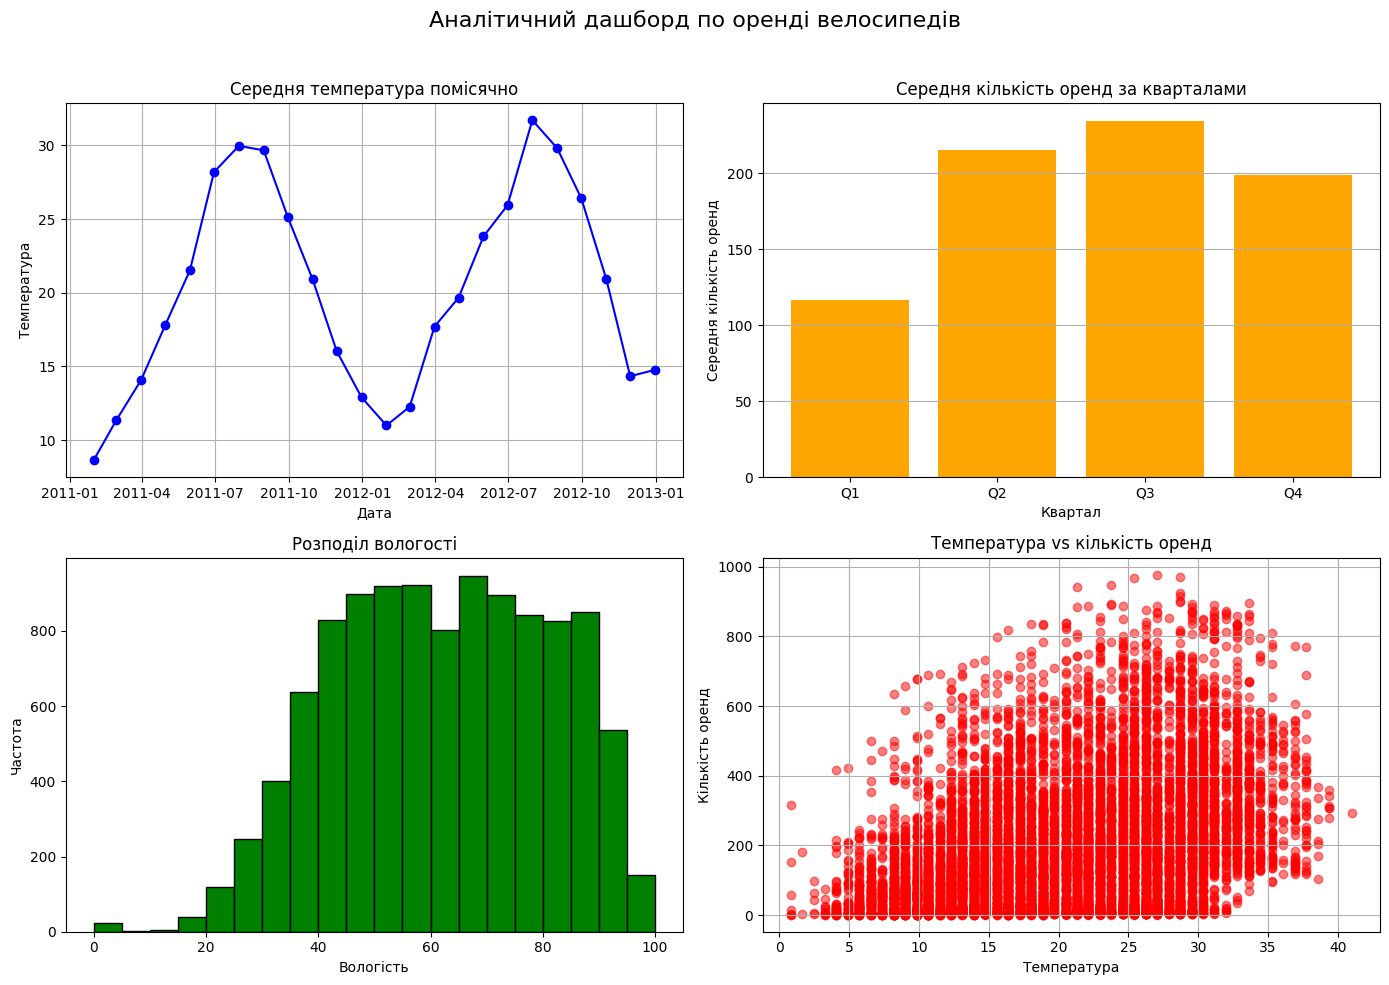

In [11]:
# Дані для графіків
monthly_temp = df['temp'].resample('M').mean()
quarter_hourly_rent = df.groupby('season')['count'].mean()

# Створюємо фігуру
plt.figure(figsize=(14, 10))

# Графік 1: лінійний графік середньої температури помісячно
plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp.values, marker='o', color='blue')
plt.title('Середня температура помісячно')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid(True)

# нрафік 2: стовпчикова діаграма середньої кількості оренд за кварталами
plt.subplot(2, 2, 2)
plt.bar(['Q1', 'Q2', 'Q3', 'Q4'], quarter_hourly_rent.values, color='orange')
plt.title('Середня кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.grid(axis='y')

# Графік 3: гістограма вологості
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='green', edgecolor='black')
plt.title('Розподіл вологості')
plt.xlabel('Вологість')
plt.ylabel('Частота')

# Графік 4: scatter plot temp vs count
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.5, color='red')
plt.title('Температура vs кількість оренд')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.grid(True)

# Заголовок усього дашборду
plt.suptitle('Аналітичний дашборд по оренді велосипедів', fontsize=16)

# Щоб графіки не налазили один на одного
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

/tmp/ipykernel_7383/4268023557.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df['temp'].resample('M').mean()


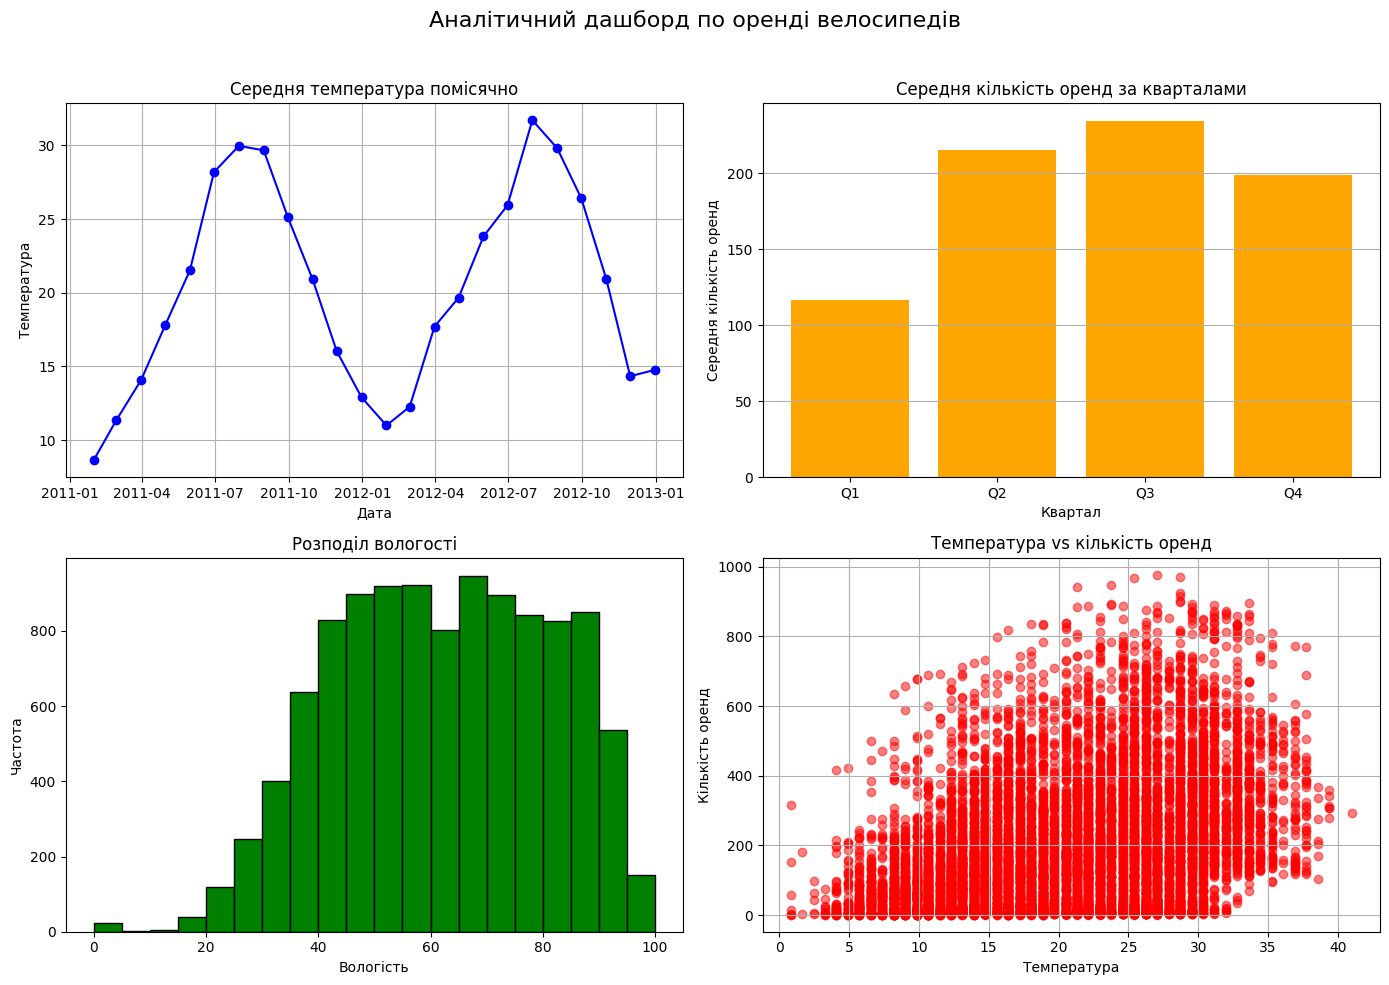

In [12]:
# Дані для графіків
monthly_temp = df['temp'].resample('M').mean()
quarter_hourly_rent = df.groupby('season')['count'].mean()

# Створюємо сітку 2x2
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Лінійний графік середньої температури помісячно
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='blue')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Дата')
ax[0, 0].set_ylabel('Температура')
ax[0, 0].grid(True)

# Стовпчикова діаграма середньої кількості оренд за кварталами
ax[0, 1].bar(['Q1', 'Q2', 'Q3', 'Q4'], quarter_hourly_rent.values, color='orange')
ax[0, 1].set_title('Середня кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')
ax[0, 1].grid(axis='y')

# Гістограма вологості
ax[1, 0].hist(df['humidity'], bins=20, color='green', edgecolor='black')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Частота')

# Scatter plot температури vs кількості оренд
ax[1, 1].scatter(df['temp'], df['count'], alpha=0.5, color='red')
ax[1, 1].set_title('Температура vs кількість оренд')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')
ax[1, 1].grid(True)

# Заголовок усього дашборду
fig.suptitle('Аналітичний дашборд по оренді велосипедів', fontsize=16)

# Щоб нічого не накладалося
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

plt.subplot() простіший підхід, коли ми щоразу окремо вказуємо позицію чергового графіка на фігурі, і далі працюємо через plt. Він підходить для невеликих і простих побудов, але при великій кількості графіків код стає менш зручним і менш наочним.

plt.subplots() одразу створює всю фігуру та набір осей (fig і ax), тому ми можемо звертатися до кожного підграфіка окремо, наприклад ax[0,1]. Такий підхід дає більше контролю над оформленням кожного графіка.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

/tmp/ipykernel_7383/2709829719.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stats = df['count'].resample('M').agg(['mean', 'min', 'max'])


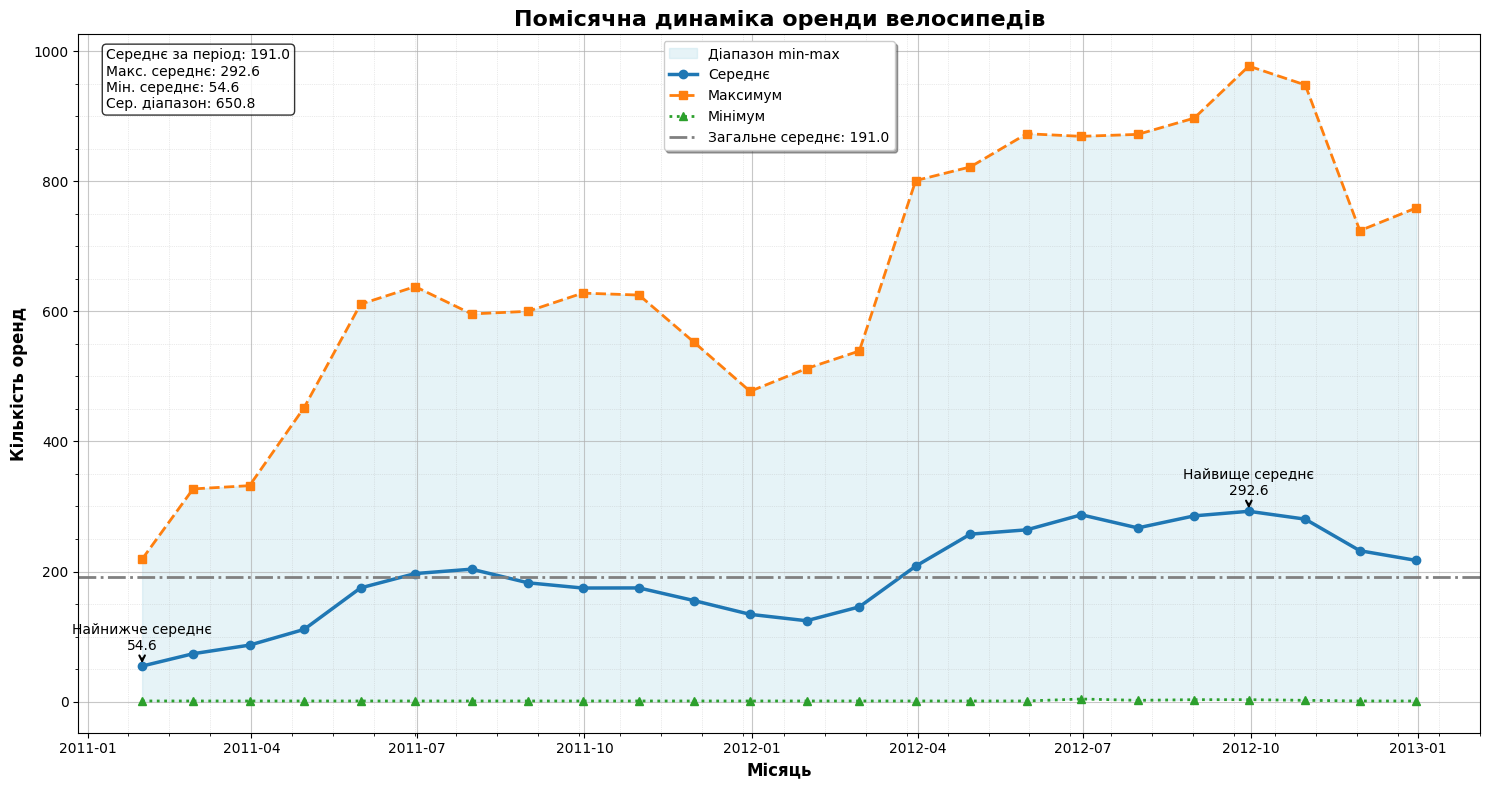

In [13]:
import numpy as np

# Групування по місяцях за весь період
monthly_stats = df['count'].resample('M').agg(['mean', 'min', 'max'])

# Загальне середнє
overall_mean = monthly_stats['mean'].mean()

# Пошук точок для анотацій
max_mean_idx = monthly_stats['mean'].idxmax()
min_mean_idx = monthly_stats['mean'].idxmin()
max_mean_val = monthly_stats['mean'].max()
min_mean_val = monthly_stats['mean'].min()

# Створення фігури
fig, ax = plt.subplots(figsize=(15, 8))

# Заливка між мінімумом і максимумом
ax.fill_between(
    monthly_stats.index,
    monthly_stats['min'],
    monthly_stats['max'],
    color='lightblue',
    alpha=0.3,
    label='Діапазон min-max'
)

# Лінії
ax.plot(
    monthly_stats.index,
    monthly_stats['mean'],
    linestyle='-',
    marker='o',
    linewidth=2.5,
    label='Середнє'
)

ax.plot(
    monthly_stats.index,
    monthly_stats['max'],
    linestyle='--',
    marker='s',
    linewidth=2,
    label='Максимум'
)

ax.plot(
    monthly_stats.index,
    monthly_stats['min'],
    linestyle=':',
    marker='^',
    linewidth=2,
    label='Мінімум'
)

# Горизонтальна лінія загального середнього
ax.axhline(
    overall_mean,
    linestyle='-.',
    linewidth=2,
    color='gray',
    label=f'Загальне середнє: {overall_mean:.1f}'
)

# Анотація для найвищого середнього
ax.annotate(
    f'Найвище середнє\n{max_mean_val:.1f}',
    xy=(max_mean_idx, max_mean_val),
    xytext=(max_mean_idx, max_mean_val + 25),
    arrowprops=dict(arrowstyle='->', lw=1.5),
    fontsize=10,
    ha='center'
)

# Анотація для найнижчого середнього
ax.annotate(
    f'Найнижче середнє\n{min_mean_val:.1f}',
    xy=(min_mean_idx, min_mean_val),
    xytext=(min_mean_idx, min_mean_val + 25),
    arrowprops=dict(arrowstyle='->', lw=1.5),
    fontsize=10,
    ha='center'
)

# Двошарова сітка
ax.minorticks_on()
ax.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

# Заголовок і підписи
ax.set_title('Помісячна динаміка оренди велосипедів', fontsize=16, fontweight='bold')
ax.set_xlabel('Місяць', fontsize=12, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=12, fontweight='bold')

# Легенда
ax.legend(frameon=True, shadow=True, fancybox=True)

# Текстовий блок зі статистикою
stats_text = (
    f'Середнє за період: {monthly_stats["mean"].mean():.1f}\n'
    f'Макс. середнє: {monthly_stats["mean"].max():.1f}\n'
    f'Мін. середнє: {monthly_stats["mean"].min():.1f}\n'
    f'Сер. діапазон: {(monthly_stats["max"] - monthly_stats["min"]).mean():.1f}'
)

ax.text(
    0.02, 0.98,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()